---
### **IMPORTS**
---

In [9]:
# goat_projection_pipeline.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple

---
### **DATA LOADING & CLEANING**
---

In [10]:
def load_knbs(filepath: str) -> pd.DataFrame:
    """Load KNBS, keep meat goats only, clean numerics."""
    df = pd.read_csv(filepath, usecols=['Year','County','Region','Goats_Meat'])
    df['Goats_Meat'] = (
        df['Goats_Meat'].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('"', '', regex=False)
    )
    df['Goats_Meat'] = pd.to_numeric(df['Goats_Meat'], errors='coerce').fillna(0)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df.dropna(subset=['Year'])
    df['Year'] = df['Year'].astype(int)

    return df

def knbs_national(filepath: str) -> pd.DataFrame:
    """National totals for meat goats."""
    df = load_knbs(filepath)
    nat = df.groupby('Year', as_index=False)['Goats_Meat'].sum().sort_values('Year')
    return nat

def load_kiamis(filepath: str) -> pd.DataFrame:
    """Load KIAMIS and normalize age strings."""
    df = pd.read_csv(filepath)
    # keep meat goats only
    meat_mask = df['livestock_sub_category'].str.contains('Meat goats', case=False, na=False) | \
                df.get('livestock_name','').astype(str).str.contains('Meat goat', case=False, na=False)
    df = df[meat_mask].copy()

    # normalize age strings for robust mapping
    def norm_age(s: str) -> str:
        s = str(s).strip().lower()
        s = s.replace('years', 'yrs').replace('year', 'yr')
        s = s.replace(' - ', '-').replace(' ', '')
        s = s.replace('to', '-')
        s = s.replace('>','').replace('+','')
        return s

    df['age_norm'] = df['livestock_age'].map(norm_age)
    return df

def kiamis_age_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate KIAMIS counts by normalized age bin."""
    agg = df.groupby('age_norm', as_index=False).agg(
        male=('male_livestock_count','sum'),
        female=('female_livestock_count','sum'),
        total=('total_livestock_count','sum')
    )
    return agg

def map_kiamis_to_model_classes(agg: pd.DataFrame) -> pd.DataFrame:
    """
    Map KIAMIS age bins to model classes:
      Kids_0_6m, Kids_6_12m, Yearlings_1_2, Adults_2_4, Adults_4_6
    """
    mapping = {
        # kids 0-6m
        'lessthan2months': 'Kids_0_6m',
        '0-2months': 'Kids_0_6m',
        '2-6months': 'Kids_0_6m',
        '3-8weeks': 'Kids_0_6m',
        # kids 6-12m
        '6-12months': 'Kids_6_12m',
        '6-12m': 'Kids_6_12m',
        # 1-2y
        '1-2years': 'Yearlings_1_2',
        '1-2yrs': 'Yearlings_1_2',
        '1-2yr': 'Yearlings_1_2',
        # 2-4y
        '2-4yrs': 'Adults_2_4',
        '2-4years': 'Adults_2_4',
        # 4+ y
        '4yrsorolder': 'Adults_4_6',
        '4-6yrs': 'Adults_4_6',
        '4-5yrs': 'Adults_4_6',
        '5-6yrs': 'Adults_4_6'
    }

    # apply mapping; collapse to model classes
    mapped = agg.copy()
    mapped['model_class'] = mapped['age_norm'].map(mapping)
    mapped = mapped.dropna(subset=['model_class'])

    model = mapped.groupby('model_class', as_index=False).agg(
        male=('male','sum'),
        female=('female','sum'),
        total=('total','sum'),
    )

    # proportions within model classes
    grand_total = model['total'].sum()
    model['prop_total']  = model['total']  / grand_total if grand_total > 0 else 0
    model['prop_female'] = model['female'] / model['total'].replace({0:np.nan})
    model['prop_male']   = model['male']   / model['total'].replace({0:np.nan})
    model = model.fillna(0.5)  # fallback if a class has 0
    return model.set_index('model_class')

---
### **BUILD A STRUCTURED 2023 BASELINE (STATE VECTOR)**
---

In [11]:
MODEL_CLASSES = ['Kids_0_6m','Kids_6_12m','Yearlings_1_2','Adults_2_4','Adults_4_6']

def build_structured_knbs(knbs_nat: pd.DataFrame,
                          kiamis_model_props: pd.DataFrame,
                          baseline_year: int) -> pd.DataFrame:
    """
    Split KNBS national total for baseline_year into age/sex classes using KIAMIS proportions.
    Returns a DataFrame with columns for each class and sex.
    """
    total = int(knbs_nat.loc[knbs_nat['Year']==baseline_year, 'Goats_Meat'].values[0])
    out = pd.DataFrame({'Year':[baseline_year], 'Goats_Meat':[total]})

    for cls in MODEL_CLASSES:
        if cls in kiamis_model_props.index:
            p_total  = float(kiamis_model_props.loc[cls,'prop_total'])
            p_f      = float(kiamis_model_props.loc[cls,'prop_female'])
            p_m      = float(kiamis_model_props.loc[cls,'prop_male'])
        else:
            p_total, p_f, p_m = 0.0, 0.5, 0.5

        n_cls  = int(round(total * p_total))
        n_f    = int(round(n_cls * p_f))
        n_m    = int(round(n_cls * p_m))

        out[f'{cls}_female'] = n_f
        out[f'{cls}_male']   = n_m

    return out

def estimate_repro_status(structured_row: pd.Series,
                          params: Dict) -> Dict[str, float]:
    """
    From age-structured females, estimate pregnant and lactating does at baseline.
    We use breeding_fraction by class, gestation/cycle math, and lactating_prop.
    """
    repro_classes = params['reproductive_classes']
    breed_frac    = params['breeding_fraction']

    # total reproductive females
    repro_f = 0.0
    for cls in repro_classes:
        repro_f += structured_row[f'{cls}_female'] * breed_frac.get(cls, 1.0)

    # pregnant proportion ~ gestation_days / reproductive cycle length (365/kidding_rate)
    cycle_days = 365.0 / max(1e-6, params['kidding_rate'])
    preg_prop  = min(0.95, params['gestation_days'] / cycle_days)

    pregnant_does = repro_f * preg_prop
    lactating_does = sum(structured_row[f'{cls}_female'] for cls in repro_classes) * params['lactating_prop']

    return {
        'pregnant_does': float(pregnant_does),
        'lactating_does': float(lactating_does)
    }

def initial_state_2023(structured_df: pd.DataFrame, params: Dict) -> pd.Series:
    """Turn the structured 2023 table into a state vector with baseline pregnant/lactating counts."""
    row = structured_df.iloc[0]
    state = pd.Series(dtype=float)

    # age/sex counts
    for cls in MODEL_CLASSES:
        state[f'{cls}_female'] = float(row[f'{cls}_female'])
        state[f'{cls}_male']   = float(row[f'{cls}_male'])

    # derived status
    repro_status = estimate_repro_status(row, params)
    state['Pregnant_does'] = repro_status['pregnant_does']
    state['Lactating_does'] = repro_status['lactating_does']
    return state

---
### **MODEL PARAMETERS**
---

In [12]:
def get_model_params() -> Dict:
    """
    Defaults chosen for slow, progressive growth. All within your requested ranges.
    Tweak to calibrate against KNBS/KIAMIS.
    """
    return {
        # Reproduction
        'kidding_rate': 1.50,           # 1.25–1.7
        'kidding_interval_months': 9.5,# 8–12
        'litter_size': 1.08,           # 1.0–1.29
        'sex_ratio_at_birth': 0.47,    # male fraction at birth
        'gestation_days': 150,         # 145–156
        'max_kiddings_per_doe': 5,     # 4–6

        # AI
        'ai_coverage': 0.10,           # up to 0.20 (0–1 scale)
        'ai_efficiency': 2.0,          # ~2.0 (informative; mild positive effect)

        # Mortality (annual)
        'kid_mortality_0_6m': 0.18,    # 8–40%
        'kid_mortality_6_12m': 0.10,   # within kid range
        'adult_mortality': 0.05,      # 5–6%

        # Vaccination (reduces mortality slightly)
        'vaccination_rate': 0.23,      # 23–46% (0–1 scale)

        # Offtake (annual class-specific; all within 10–30%)
        'offtake_rates': {
            'Kids_0_6m': 0.05,
            'Kids_6_12m': 0.09,
            'Yearlings_1_2': 0.07,
            'Adults_2_4': 0.10,
            'Adults_4_6': 0.15
        },

        # Who breeds (fraction of females in class that actually breed)
        'breeding_fraction': {
            'Yearlings_1_2': 0.55,
            'Adults_2_4': 0.78,
            'Adults_4_6': 0.58  # slightly reduced for age / max kiddings
        },
        'reproductive_classes': ['Yearlings_1_2','Adults_2_4','Adults_4_6'],

        # Production
        'lactating_prop': 0.58,        # fraction of reproductive females lactating
        'milk_yield_per_day': 1.7,     # 1.4–2.5
        'lactation_days': 180,         # 218–252

        # Weights & DMI (% of body weight)
        'avg_weights': {
            'Kids_0_6m': 8,   # birth ~2.5 → ~18 at 6m → avg ~10
            'Kids_6_12m': 18,  # 18–20
            'Yearlings_1_2': 35,
            'Adults_2_4': 55,  # adult does 50–60 (avg 55)
            'Adults_4_6': 55   # older adults a bit heavier
        },
        'dmi_pct': {
            'Kids_0_6m': 0.03, 
            'Kids_6_12m': 0.03,
            'Yearlings_1_2': 0.03, 
            'Adults_2_4': 0.035, 
            'Adults_4_6': 0.035
        },

        # Carcass yield
        'carcass_yield': {
            'Kids_0_6m': 0.45, 
            'Kids_6_12m': 0.45, 
            'Yearlings_1_2': 0.42,
            'Adults_2_4': 0.40, 
            'Adults_4_6': 0.40
        },

        # Management constraints
        'male_retention_pct': 0.04,    # 4–5% of does kept as breeding bucks
        'carrying_capacity': None,     # set to int to apply density dependence
        'birth_timing': 'mid',         # 'pre', 'post', or 'mid' (recommended)
    }

# Helper to apply AI & vaccination effects modestly
def effective_fertility_multiplier(params: Dict) -> float:
    # small bonus for AI coverage
    ai_bonus = 1.0 + 0.10 * float(params.get('ai_coverage',0.0))  # up to +2%
    return ai_bonus

def effective_mortality(base_rate: float, params: Dict) -> float:
    # simple linear reduction from vaccination
    v = float(params.get('vaccination_rate',0.0))  # 0–1
    return max(0.0, base_rate * (1 - 0.2 * v))     # up to 9.2% lower at v=0.46

---
### **COHORT MODEL (ANNUAL TIMESTEP)**
---

In [13]:
def simulate_one_year(state: pd.Series, params: Dict) -> Tuple[pd.Series, Dict[str, float]]:
    """
    One-step annual cohort update with smoothed 'mid-year births'.
    Returns (next_state, production)
    """
    classes = MODEL_CLASSES
    next_state = pd.Series(0.0, index=state.index, dtype=float)
    prod = {'milk_liters':0.0, 'meat_kg':0.0, 'feed_kg':0.0}

    # precompute effective fertility & mortality
    fert_mult = effective_fertility_multiplier(params)
    kid_mort_0_6 = effective_mortality(params['kid_mortality_0_6m'], params)
    kid_mort_6_12 = effective_mortality(params['kid_mortality_6_12m'], params)
    adult_mort = effective_mortality(params['adult_mortality'], params)

    # choose timing
    timing = params.get('birth_timing','mid')

    # --- utility: mortality by class name
    def mort_rate_for(cls):
        if cls == 'Kids_0_6m':
            return kid_mort_0_6
        elif cls == 'Kids_6_12m':
            return kid_mort_6_12
        else:
            return adult_mort

    # ----------------------
    # A) births (timing)
    # ----------------------
    def compute_births_from(pop_source: pd.Series) -> Tuple[float,float]:
        """Compute male_kids, female_kids from a population source (state or mid-year survivors)."""
        repro_does = 0.0
        for cls in params['reproductive_classes']:
            repro_does += float(pop_source.get(f'{cls}_female', 0.0)) * params['breeding_fraction'].get(cls,1.0)

        # effective kidding rate bounded by interval
        k_from_interval = 12.0 / max(1e-6, params['kidding_interval_months'])
        effective_kidding = min(params['kidding_rate'], k_from_interval) * fert_mult

        kids_born = repro_does * effective_kidding * params['litter_size']

        # density dependence (optional)
        total_now = sum(float(pop_source.get(f'{c}_female',0.0) + pop_source.get(f'{c}_male',0.0)) for c in classes)
        K = params.get('carrying_capacity', None)
        if K and K > 0:
            density = max(0.6, 1.0 - total_now / float(K))  # keep some reproduction even near K
            kids_born *= density

        # pre-weaning survival
        kids_survive = kids_born * (1 - kid_mort_0_6)
        male_kids   = kids_survive * params['sex_ratio_at_birth']
        female_kids = kids_survive * (1 - params['sex_ratio_at_birth'])
        return male_kids, female_kids

    # ----------------------
    # B) event ordering
    # ----------------------
    if timing == 'pre':
        # births from start-of-year state (no mid-year smoothing)
        mk, fk = compute_births_from(state)
    elif timing == 'post':
        # births from end-of-year (after ageing) -> we’ll compute later on next_state snapshot
        mk, fk = 0.0, 0.0
    else:  # 'mid' (recommended)
        # apply half-year mortality (smooths dips), then compute births from mid-year survivors
        mid_state = {}
        for cls in classes:
            f0 = float(state[f'{cls}_female']); m0 = float(state[f'{cls}_male'])
            mr = mort_rate_for(cls)
            f_mid = f0 * (1 - mr*0.5)
            m_mid = m0 * (1 - mr*0.5)
            mid_state[f'{cls}_female'] = f_mid
            mid_state[f'{cls}_male']   = m_mid
        mk, fk = compute_births_from(pd.Series(mid_state))

    # ----------------------
    # C) mortality + ageing (on full-year)
    # ----------------------
    for i, cls in enumerate(classes):
        f = float(state[f'{cls}_female'])
        m = float(state[f'{cls}_male'])
        mr = mort_rate_for(cls)

        # for 'mid' timing, remaining half-year mortality has already been half applied via births calculation;
        # but for the population update we apply full-year mortality once (this is still a simplification).
        f_survive = f * (1 - mr)
        m_survive = m * (1 - mr)

        # age progression
        if i < len(classes) - 1:
            next_cls = classes[i+1]
            next_state[f'{next_cls}_female'] += f_survive
            next_state[f'{next_cls}_male']   += m_survive
        else:
            next_state[f'{cls}_female'] += f_survive
            next_state[f'{cls}_male']   += m_survive

        # feed (approx. use survivors as average headcount)
        weight = params['avg_weights'][cls]
        dmi    = params['dmi_pct'][cls]
        prod['feed_kg'] += (f_survive + m_survive) * weight * dmi * 365.0

    # births placement
    if timing == 'post':
        # compute births from post-ageing survivors (more conservative)
        mk, fk = compute_births_from(next_state)

    # add newborns into 0-6m
    next_state['Kids_0_6m_male']   += mk
    next_state['Kids_0_6m_female'] += fk

    # ----------------------
    # D) offtake & meat
    # ----------------------
    for cls in classes:
        rate = params['offtake_rates'].get(cls, 0.0)
        f_remove = next_state[f'{cls}_female'] * rate
        m_remove = next_state[f'{cls}_male']   * rate

        # ensure male retention for breeding: keep a minimum # of adult bucks
        if cls in ['Adults_2_4','Adults_4_6']:
            total_does = sum(next_state[f'{c}_female'] for c in params['reproductive_classes'])
            min_bucks = params['male_retention_pct'] * total_does
            adult_bucks = next_state['Adults_2_4_male'] + next_state['Adults_4_6_male']
            deficit = max(0.0, min_bucks - adult_bucks + m_remove)  # what we'd have *after* removal
            if deficit > 0:
                m_remove = max(0.0, m_remove - deficit)

        # meat
        w = params['avg_weights'][cls]
        cy = params['carcass_yield'][cls]
        prod['meat_kg'] += (f_remove + m_remove) * w * cy

        # apply removal
        next_state[f'{cls}_female'] -= f_remove
        next_state[f'{cls}_male']   -= m_remove

    # ----------------------
    # E) milk production
    # ----------------------
    lactating_does = sum(next_state[f'{cls}_female'] for cls in params['reproductive_classes']) * params['lactating_prop']
    prod['milk_liters'] = lactating_does * params['milk_yield_per_day'] * params['lactation_days']

    # (Optional) update status counters
    next_state['Pregnant_does'] = sum(next_state[f'{cls}_female'] * params['breeding_fraction'].get(cls,1.0)
                                      for cls in params['reproductive_classes']) * \
                                  min(0.95, params['gestation_days'] / (365.0 / max(1e-6, params['kidding_rate'])))
    next_state['Lactating_does'] = lactating_does

    return next_state, prod

---
### **SIMULATE PROJECTIONS (2024-2033)**
---

In [14]:
def project_population(initial_state: pd.Series, params: Dict, years: int, start_year: int) -> pd.DataFrame:
    rows = []
    state = initial_state.copy()
    for i in range(years):
        state, prod = simulate_one_year(state, params)
        total_pop = sum(float(state[k]) for k in state.index if k.endswith('_female') or k.endswith('_male'))
        row = {'Year': start_year + i + 1, 'total_population': total_pop}
        row.update(prod)
        # snapshot of classes
        for cls in MODEL_CLASSES:
            row[f'{cls}_female'] = float(state[f'{cls}_female'])
            row[f'{cls}_male']   = float(state[f'{cls}_male'])
        rows.append(row)
    return pd.DataFrame(rows)

---
### **VISUALIZATION**
---

In [15]:
def plot_history_vs_projection(knbs_nat: pd.DataFrame, projections: pd.DataFrame):
    plt.figure(figsize=(7,5))
    plt.plot(knbs_nat['Year'], knbs_nat['Goats_Meat'], 'o--', label='KNBS (historical)')
    plt.plot(projections['Year'], projections['total_population'], 'o-', label='Projection')
    plt.title('Total Population: Historical vs Projection')
    plt.xlabel('Year'); plt.ylabel('Population'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

def plot_production(projections: pd.DataFrame):
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    axes[0].plot(projections['Year'], projections['milk_liters'], 'o-')
    axes[0].set_title('Milk Production'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Liters'); axes[0].grid(True)

    axes[1].plot(projections['Year'], projections['meat_kg'], 'o-')
    axes[1].set_title('Meat Production'); axes[1].set_xlabel('Year'); axes[1].set_ylabel('Kg'); axes[1].grid(True)

    axes[2].plot(projections['Year'], projections['feed_kg'], 'o-')
    axes[2].set_title('Feed Requirements'); axes[2].set_xlabel('Year'); axes[2].set_ylabel('Kg'); axes[2].grid(True)
    plt.tight_layout(); plt.show()

def plot_age_classes(projections: pd.DataFrame):
    fig, axes = plt.subplots(2,3, figsize=(18,8))
    axes = axes.flatten()
    for i, cls in enumerate(MODEL_CLASSES):
        ax = axes[i]
        ax.plot(projections['Year'], projections[f'{cls}_female'], label='Female')
        ax.plot(projections['Year'], projections[f'{cls}_male'], label='Male')
        ax.set_title(cls.replace('_',' ').replace('Kids','Kids'))
        ax.set_xlabel('Year'); ax.set_ylabel('Population'); ax.grid(True); ax.legend()
    # hide last empty subplot if any
    if len(MODEL_CLASSES) < len(axes):
        axes[-1].axis('off')
    plt.tight_layout(); plt.show()

---
### **MODEL OUTPUTS**
---

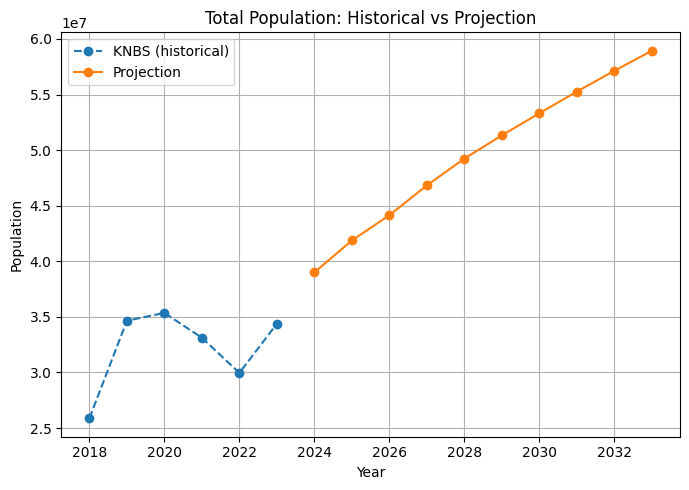

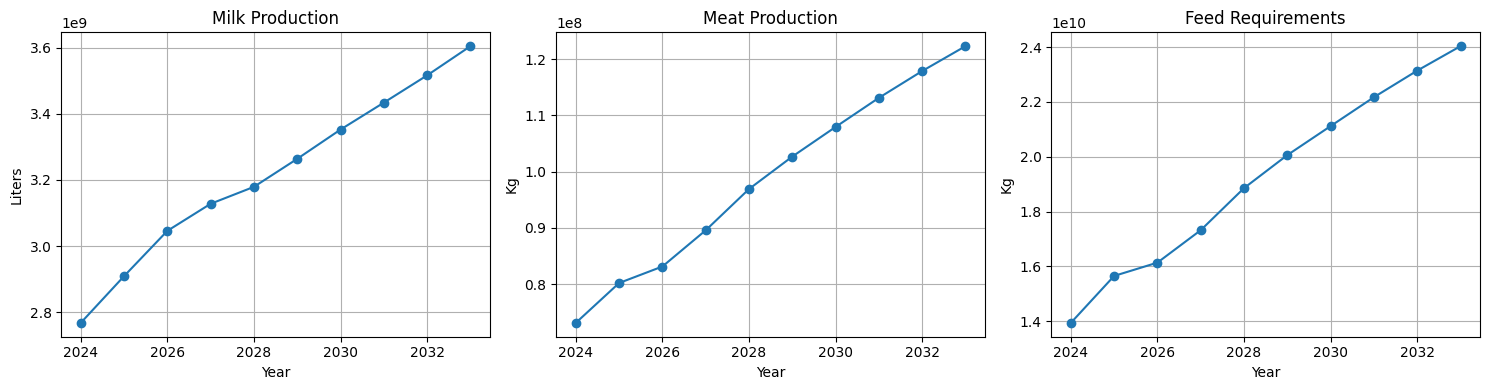

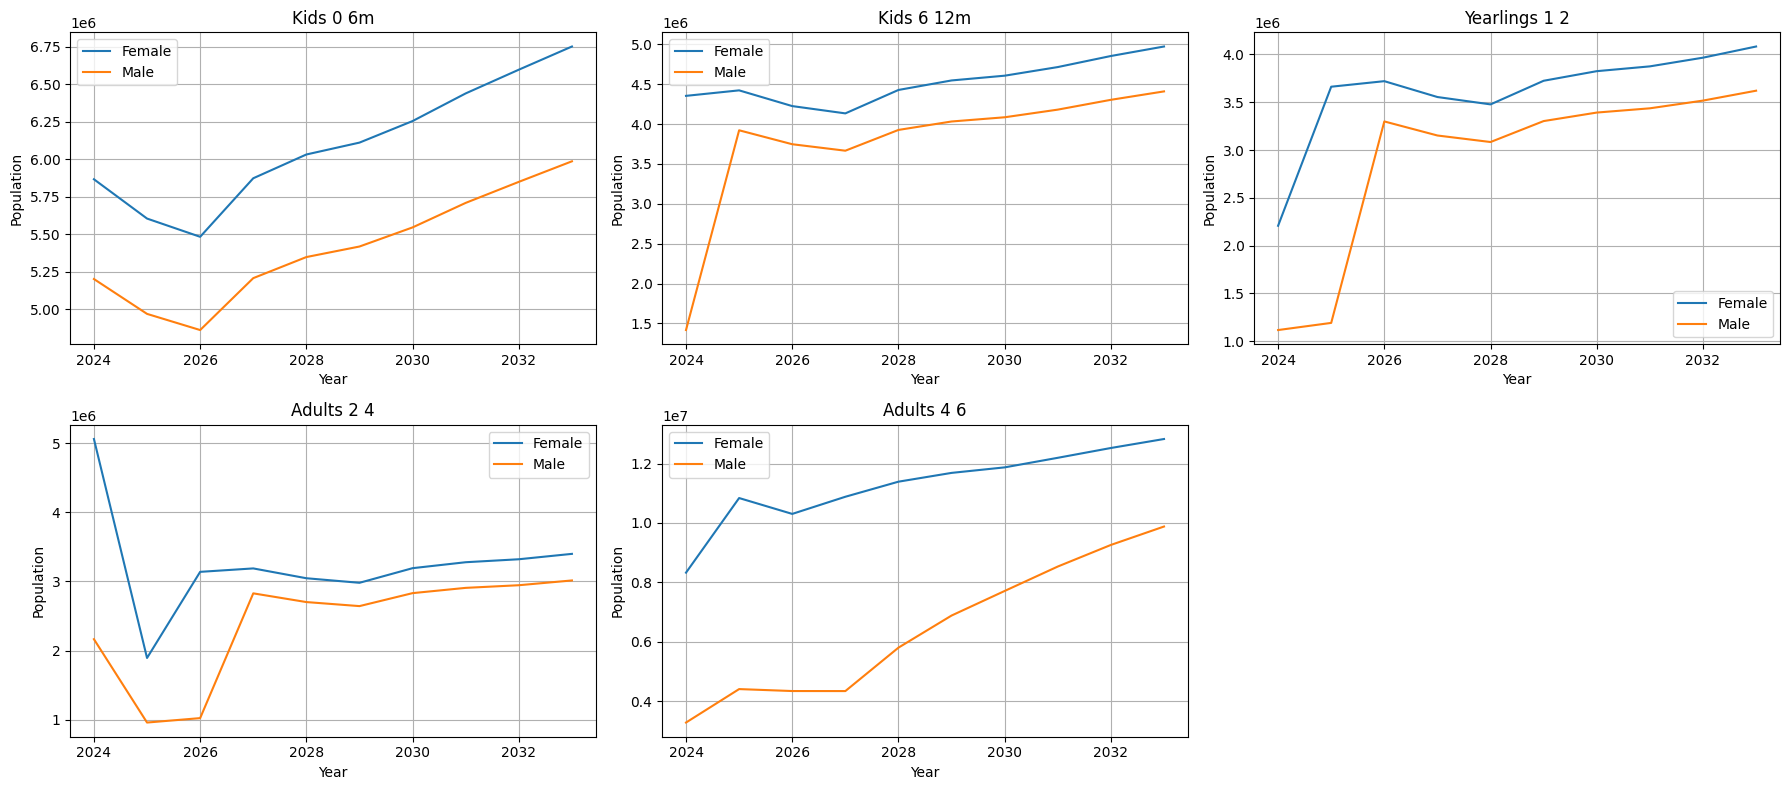

In [16]:
# --- file paths ---
KNBS_CSV   = "data/knbs_population.csv"
KIAMIS_CSV = "data/kiamis_livestock.csv"
BASELINE_YEAR = 2023
YEARS_AHEAD = 10

# A) load & prep data
knbs_nat = knbs_national(KNBS_CSV)
kiam_raw = load_kiamis(KIAMIS_CSV)
kiam_agg = kiamis_age_distribution(kiam_raw)
kiam_model = map_kiamis_to_model_classes(kiam_agg)

# B) build structured baseline and initial state (2023)
params = get_model_params()
structured_2023 = build_structured_knbs(knbs_nat, kiam_model, BASELINE_YEAR)
state_2023 = initial_state_2023(structured_2023, params)

# C) project
projections = project_population(state_2023, params, years=YEARS_AHEAD, start_year=BASELINE_YEAR)

# D) plots
plot_history_vs_projection(knbs_nat, projections)
plot_production(projections)
plot_age_classes(projections)